In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [60]:
import os

os.chdir(r"C:\Users\Ranjeet Ramesh More\OneDrive\Desktop\Data Analytics Course\Python projects\Customer Churn Analysis")

In [61]:
print(os.getcwd())

C:\Users\Ranjeet Ramesh More\OneDrive\Desktop\Data Analytics Course\Python projects\Customer Churn Analysis


In [62]:
import os

print(os.path.exists("customer_churn.db"))

True


In [63]:
# 1 Creating a connection

In [64]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

print("Tables found:")
print(tables)

# Create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Tables found:
              name
0      db_customer
1  db_subscription
2       db_support
Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [65]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [66]:
# 2 Data Cleaning

In [67]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [68]:
# a. rename column - name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. Data Standarization - gender
# e. fix missing values - country


In [69]:
# a. rename column - name
df_db_customer.rename(columns = {'name' : 'customer_name'},inplace = True)


In [70]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [71]:
# b. drop columns - interest and pincode 
#df_db_customer.drop(df_db_customer.columns[-2:],axis = 1)
#df_db_customer.drop(df_db_customer.columns[6:],axis = 1)
df_db_customer.drop(columns = ['interests','pincode'],inplace = True)

In [72]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [73]:
# c. change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [74]:
# d. Data Standarization - gender
#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})


In [75]:
# e. fix missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [76]:
#country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [77]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [78]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [79]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [80]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [81]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [82]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [83]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [84]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [85]:
df_db_support.drop(columns = ['col_1','comment'],inplace = True)

In [86]:
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score'], dtype='object')

In [87]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [88]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [89]:
# 3. Feature Engineering and Data Analysis 

In [90]:
# Create a new column using existing column
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [91]:
df = (df_db_subscription.merge(df_db_customer, on = 'customerid',how = 'left')
                        .merge(df_db_support, on = 'customerid',how = 'left'))

In [92]:
df_db_subscription.shape


(21, 12)

In [93]:
df.shape # important step to check rows and values.

(23, 20)

In [94]:
df_db_subscription['customerid'].nunique()

21

In [95]:
df_db_customer['customerid'].nunique()

21

In [96]:
df_db_support['customerid'].nunique()

7

In [97]:
df_db_support['customerid'].size

9

In [98]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [99]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [100]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [101]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [102]:
df_db_support['customerid'].size

7

In [103]:
df = (df_db_subscription.merge(df_db_customer, on = 'customerid',how = 'left')
                        .merge(df_db_support, on = 'customerid',how = 'left'))

In [104]:
df.shape # now it is fixed

(21, 21)

In [105]:
# Importing data into csv file
df.to_csv('exported_churn_data.csv',index = False)

In [106]:
# 3 Data Analysis

In [107]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [108]:
# 1 Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("churn Rate = ",round(churn_rate,2),"%")

churn Rate =  28.57 %


In [109]:
# 2 retension Rate
retention_rate = 100 - churn_rate
print("Retension Rate =",round(retention_rate,2), "%")

Retension Rate = 71.43 %


In [110]:
# 3 churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [111]:
# 4 a churn by state + sum(revenue) & count of users  -- homework --
# b churn by subscription type + sum(revenue) & count of users -- homework -- 

In [112]:
# 5  ARPU - Avg Revenue per User
arpu = df['monthly_charges'].mean()
print("ARPU =",round(arpu,2))

ARPU = 18.85


In [113]:
# 6 a Avg customer tenure
#  bcount of days user has used our service : cancellation date else current date

today = pd.Timestamp.today()
df['tenure_days'] = np.where ( 
                     df['cancellation_date'].notna(),
                    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                    (today - df['subscription_start_date']).dt.days
                    )

average_tenure = df['tenure_days'].mean()
print("Average Tenure =",round(average_tenure),0)


Average Tenure = 1550 0


In [114]:
# 7 Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag'] == 1,'monthly_charges'].sum()
print("Revenue at risk (Rs k)  =", revenue_at_risk)

Revenue at risk (Rs k)  = 73.94


In [115]:
# 8 Esclation Rate
escaltion_rate = (df['escalations'] =='Y').mean()*100
print("Escalation Rate =",round(escaltion_rate,2),"%")

Escalation Rate = 19.05 %


In [116]:
# 9 Avg complaint per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg complaints per user =",round(avg_complaints,2))

Avg complaints per user = 0.43


In [117]:
print(df)

    customerid subscription_start_date subscription_type renewal_date  \
0   0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1   0003-MKNFE              2020-08-01              Paid   2024-08-01   
2   0004-TLHLJ              2022-11-20           Organic   2025-11-20   
3   0011-IGKFF              2019-05-10              Paid   2025-05-10   
4   0013-EXCHZ              2023-01-05          Refferal   2024-01-05   
5   0013-MHZWF              2022-06-18              Paid   2025-06-18   
6   0013-SMEOE              2021-09-30          Refferal   2024-09-30   
7   0014-BMAQU              2020-02-14           Organic   2025-02-14   
8   0015-UOCOJ              2023-07-22           Organic   2024-07-22   
9   0016-QLJIS              2022-04-03           Organic   2025-04-03   
10  0017-DINOC              2021-12-01           Organic   2025-12-01   
11  0017-IUDMW              2023-03-17          Refferal   2024-03-17   
12  0018-NYROU              2020-10-09           Or

In [118]:
# 10 Correlation Escalation vs Churn
df['escalations'] = df['escalations'].str.strip().map({
    'Y': 1,
    'N': 0
})
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation between escalation vs churn =", round(correlation, 2))
   

Correlation between escalation vs churn = 0.47


In [119]:
print(df['escalations'].unique())


[nan  1.  0.]


In [120]:
# 11. Create a column using a new column - churn risk
conditions = [
         (df['churn_score'] < 50),
         (df['churn_score'] >= 50) & (df['churn_score'] < 70),
         (df['churn_score'] >= 70)
]

choices = ['Low','Medium','High']

df['churn_risk'] = np.select(conditions,choices,default = 'unknown') 

In [121]:
df[['churn_risk','churn_score']].tail()


,churn_risk,churn_score
16,Medium,62
17,Low,27
18,High,99
19,Low,7
20,Low,47


In [122]:
# 4 Visualization using matplotlib

In [123]:
df_visual = df.copy()
print(df_visual)

    customerid subscription_start_date subscription_type renewal_date  \
0   0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1   0003-MKNFE              2020-08-01              Paid   2024-08-01   
2   0004-TLHLJ              2022-11-20           Organic   2025-11-20   
3   0011-IGKFF              2019-05-10              Paid   2025-05-10   
4   0013-EXCHZ              2023-01-05          Refferal   2024-01-05   
5   0013-MHZWF              2022-06-18              Paid   2025-06-18   
6   0013-SMEOE              2021-09-30          Refferal   2024-09-30   
7   0014-BMAQU              2020-02-14           Organic   2025-02-14   
8   0015-UOCOJ              2023-07-22           Organic   2024-07-22   
9   0016-QLJIS              2022-04-03           Organic   2025-04-03   
10  0017-DINOC              2021-12-01           Organic   2025-12-01   
11  0017-IUDMW              2023-03-17          Refferal   2024-03-17   
12  0018-NYROU              2020-10-09           Or

In [124]:
# 4. 1 Monthly churn Trend (Time series Kpi)

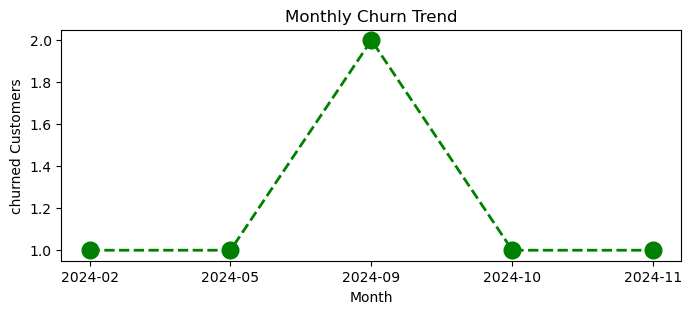

In [125]:
df_visual['cancellation_Month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_Month').size()

plt.figure(figsize = (8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color = 'green' , marker = 'o',linestyle = 'dashed', linewidth = 2, markersize = 12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('churned Customers')
plt.show()

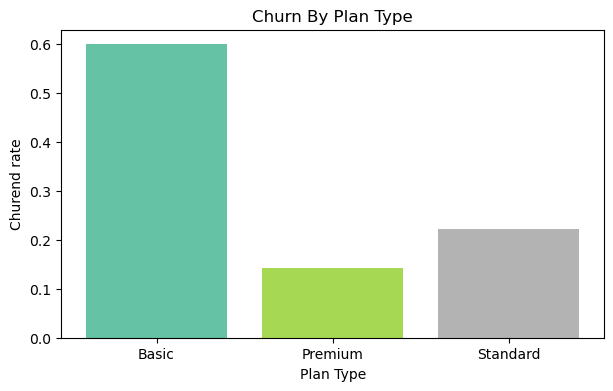

In [126]:
# 4. 2 Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize = (7,4))

# colors = ['orange','pink','blue'] --> Can give specific colors
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan))) # dynamically colors given. 

plt.bar(churn_plan.index,churn_plan.values,color = colors)


plt.title('Churn By Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churend rate')
plt.show()

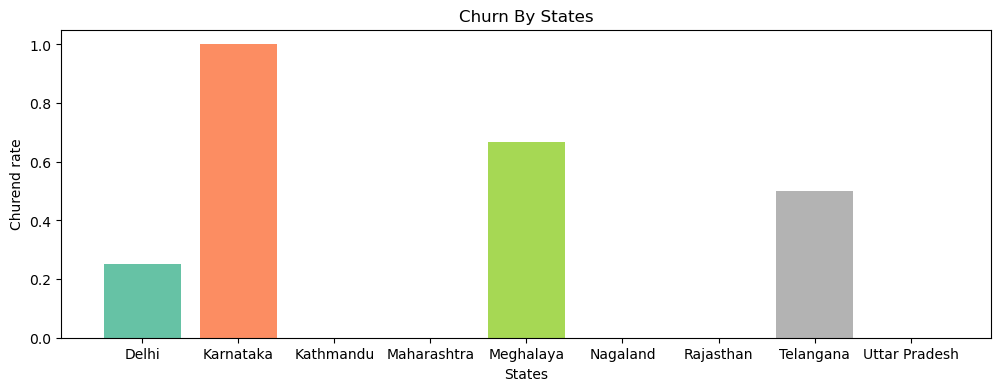

In [127]:
# 4. 2 Churn by States
churn_states = df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize = (12,4))

# colors = ['orange','pink','blue'] --> Can give specific colors
colors = plt.cm.Set2(np.linspace(0,1,len(churn_states))) # dynamically colors given. 

plt.bar(churn_states.index,churn_states.values,color = colors)


plt.title('Churn By States')
plt.xlabel('States')
plt.ylabel('Churend rate')
plt.show()

In [128]:
# Home wrok
# contract_type
# country
# gender

In [129]:
# 5 Visualization Using seaborn

In [130]:
# encoding - convert string into numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_Month'],
      dtype='object')

In [131]:
# Fix missing values and floating point type for escalations
df['escalations'] = df['escalations'].fillna(0).astype(int)

# Convert churn_risk text to lowercase
df['churn_risk'] = df['churn_risk'].str.lower()

# Display the updated dataframe subset
df[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [132]:
print(df_visual)

    customerid subscription_start_date subscription_type renewal_date  \
0   0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1   0003-MKNFE              2020-08-01              Paid   2024-08-01   
2   0004-TLHLJ              2022-11-20           Organic   2025-11-20   
3   0011-IGKFF              2019-05-10              Paid   2025-05-10   
4   0013-EXCHZ              2023-01-05          Refferal   2024-01-05   
5   0013-MHZWF              2022-06-18              Paid   2025-06-18   
6   0013-SMEOE              2021-09-30          Refferal   2024-09-30   
7   0014-BMAQU              2020-02-14           Organic   2025-02-14   
8   0015-UOCOJ              2023-07-22           Organic   2024-07-22   
9   0016-QLJIS              2022-04-03           Organic   2025-04-03   
10  0017-DINOC              2021-12-01           Organic   2025-12-01   
11  0017-IUDMW              2023-03-17          Refferal   2024-03-17   
12  0018-NYROU              2020-10-09           Or

In [133]:
# Incorect Method of encoding  - as numbers are not assigned based on priority 
# Select columns from cleaned df
df_encoded = df[['plan_type', 'contract_type', 'churn_score',
                 'churn_flag', 'churn_risk', 'escalations']].copy()

# Categorical columns
categorical_columns = ['plan_type', 'contract_type', 'churn_risk']

# Convert text categories into numbers
for col in categorical_columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Display first 5 rows
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

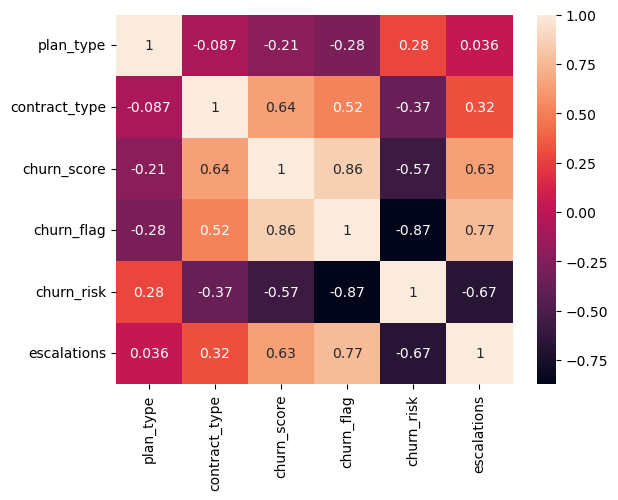

In [134]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(),annot = True)

In [135]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [136]:
# Correct method of encoding - based on priority

# Select columns from cleaned dataframe
df_encoded = df[['plan_type', 'contract_type', 'churn_score',
                 'churn_flag', 'churn_risk', 'escalations']].copy()

# Define priority/order
order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'medium', 'high']
}

# Encode based on defined order
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

# Display result
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [137]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [138]:
df[['plan_type', 'contract_type', 'churn_score',
                 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [139]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

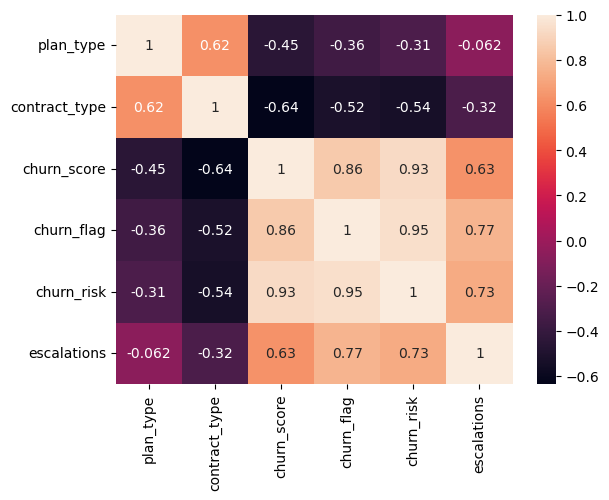

In [140]:
sns.heatmap(df_encoded.corr(),annot = True)

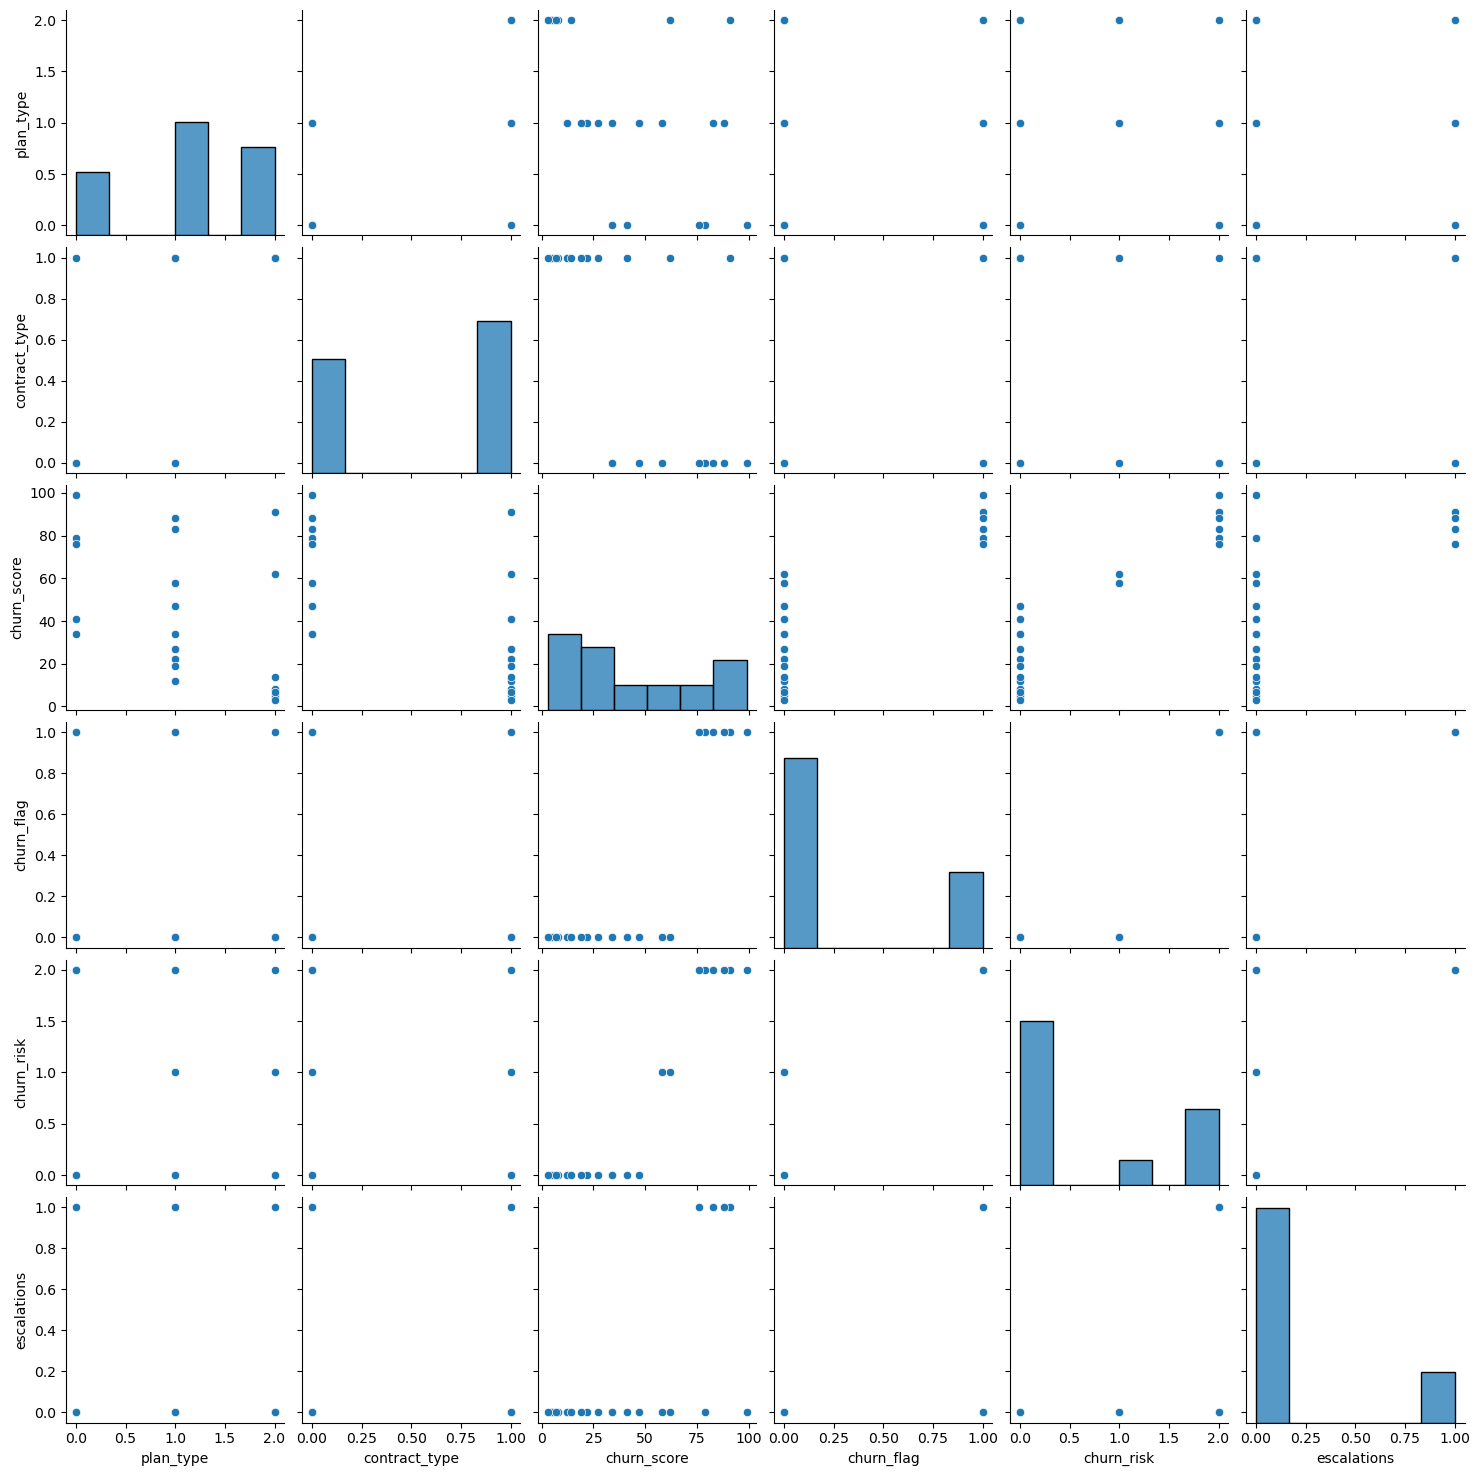

In [141]:
sns.pairplot(df_encoded)

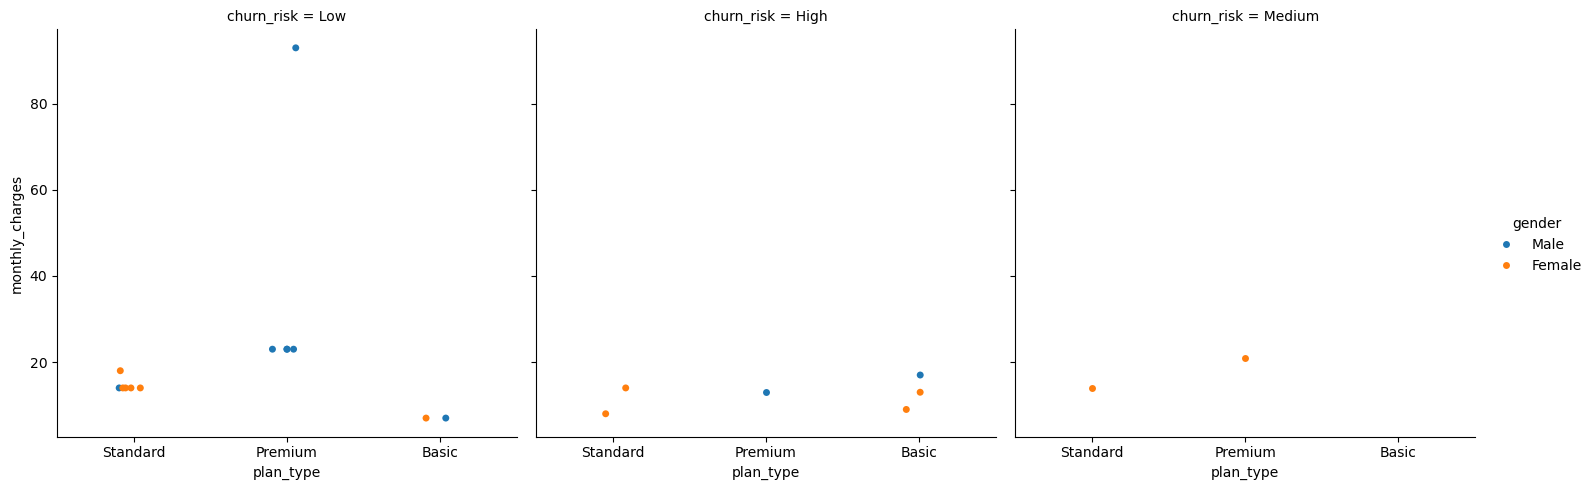

In [142]:
# catplt / Facdgrid plot - multi - dim comparision

sns.catplot(data = df_visual,
    x = 'plan_type',
    y = 'monthly_charges',
    hue = 'gender',
    col = 'churn_risk' )

In [143]:
# Pivot tables
pd.pivot_table(
    df,
    index  = 'plan_type',
    values = 'churn_flag',
    aggfunc = 'mean' )

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [144]:
pd.pivot_table(
    df,
    index  = 'plan_type',
    values = ['monthly_charges','customerid','churn_flag'],
    aggfunc = {
         'monthly_charges' : 'sum',
         'customerid' : 'nunique',
         'churn_flag' : 'mean'
    })

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [145]:
# Working with Sql in python (pands)

In [8]:
# Create database in SQL
conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("CREATE TABLE IF NOT EXISTS usersData(first_name TEXT, country TEXT, budget INTEGER)")

# Commit and save
conn.commit()


In [10]:
cursor = conn.cursor()

cursor.execute("""
    INSERT INTO usersData VALUES
        ('Ranjeet', 'India', 5000),
        ('Sumeet', 'USA', 10000),
        ('Bhakti', 'India', 15000)
""")

conn.commit()
print("Data inserted successfully !")

Data inserted successfully !


In [11]:
# Check inserted data in table
import sqlite3
import pandas as pd

# Check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM usersData """

df_results = pd.read_sql(query, conn)
df_results.head()

,first_name,country,budget
0,Ranjeet,India,5000
1,Sumeet,USA,10000
2,Bhakti,India,15000


In [12]:
# aggregation

# Connect to database
conn = sqlite3.connect('test_database.sqlite')

# Aggregation query
query = """
    SELECT country, SUM(budget) as total_budget
    FROM usersData
    GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,India,20000
1,USA,10000


In [13]:
conn.close()